[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/Embed_Clinical_Sequences_Asplenic/blob/main/notebook.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/giordamaug/Embed_Clinical_Sequences_Asplenic/HEAD?urlpath=%2Fdoc%2Ftree%2Fnotebook.ipynb)

# Experiments

## Libraries

In [1]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
from sklearn.metrics import (
    matthews_corrcoef, confusion_matrix, accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import lightgbm as lgb
import seaborn as sns
from tqdm.notebook import tqdm
import sys, os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


## Download data from Github

In [2]:
try:
    import google.colab
    !git clone https:/github.com/giordamaug/Embed_Clinical_Sequences_Asplenic.git
    %cd Embed_Clinical_Sequences_Asplenic
    print("Working on Colab!")
except:
    pass

## Load dataset

In [8]:
import pandas as pd
df = pd.read_json(f"data/dataset_EN.json").set_index("id")

### plot disease distributions

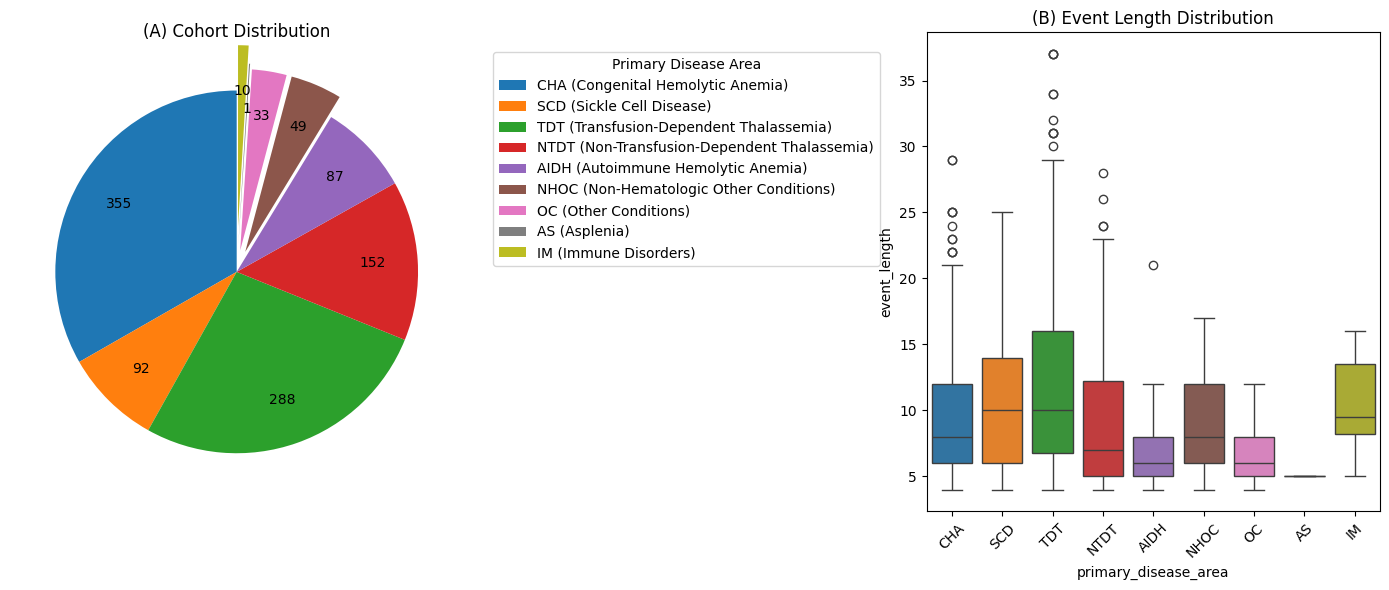

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

results_dir = "results_rev2"
label_order = ['CHA','SCD','TDT','NTDT','AIDH','NHOC','OC','AS','IM']
label_desc = {
    'CHA': 'Congenital Hemolytic Anemia',
    'SCD': 'Sickle Cell Disease',
    'TDT': 'Transfusion-Dependent Thalassemia',
    'NTDT': 'Non-Transfusion-Dependent Thalassemia',
    'AIDH': 'Autoimmune Hemolytic Anemia',
    'NHOC': 'Non-Hematologic Other Conditions',
    'OC': 'Other Conditions',
    'AS': 'Asplenia',
    'IM': 'Immune Disorders'
}
palette = sns.color_palette("tab10", len(label_order))
palette_dict = dict(zip(label_order, palette))
selected_ids = pd.read_csv(f"config/ALL_index.csv", header=None).values.ravel()
df = df.loc[selected_ids]
df['event_length'] = df['events'].apply(len)
counts = df['primary_disease_area'].value_counts()
mapping = {i: label for i, label in enumerate(label_order)}
df['primary_disease_area'] = df['primary_disease_area'].map(mapping)
counts = df['primary_disease_area'].value_counts().reindex(label_order).fillna(0)

values = counts.values
labels = counts.index

# 🔥 explode più forte per classi piccole
explode = []
for l, v in zip(labels, values):
    if l in ['IM']:
        explode.append(0.25)   # molto separati
    elif l in ['AS']:
        explode.append(0.15)   # molto separati
    elif v < np.percentile(values, 40):
        explode.append(0.12)
    else:
        explode.append(0)

# solo valori assoluti (più piccoli e leggibili)
def autopct_abs(pct):
    total = np.sum(values)
    val = int(round(pct * total / 100.0))
    return f'{val}' if val > 0 else ''

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ---------------- PIE ----------------
wedges, texts, autotexts = axes[0].pie(
    values,
    labels=None,  # 🔥 niente label interne
    colors=[palette_dict[l] for l in labels],
    explode=explode,
    autopct=autopct_abs,
    pctdistance=0.75,
    startangle=90
)

axes[0].set_title("(A) Cohort Distribution")

legend_labels = [f"{k} ({label_desc[k]})" for k in labels]
axes[0].legend(
    wedges,
    legend_labels,
    title="Primary Disease Area",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# ---------------- BOXPLOT ----------------
sns.boxplot(
    data=df,
    x='primary_disease_area',
    y='event_length',
    order=label_order,
    hue='primary_disease_area',
    palette=palette_dict,
    dodge=False,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("(B) Event Length Distribution")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Cohort selection and settings

In [10]:
groupname = "NTDT+TDT"         # patient groups: ALL, NTDT+TDT
selected_ids = pd.read_csv(f"config/{groupname}_index.csv", header=None).values.ravel()
results_dir = "results"   # in "results_rev2" you find paper's results
niter = 1                 # number of repeated cv
num_epochs = 10           # number of epochs for training
batch_size = 32           # batch size in training
embedding_dim = 64        # embedding size
hidden_dim = 128
seed = 42
enable_plot = True
methods=['STATIC', 'BINARY', 'DOME', 'LSTM', 'tLSTM', 'GRU', 'GRU-D', 'BEHRT', 'RETAIN', 'Dipole']
dataset = df.loc[selected_ids]
dataset

,is_splenectomized?,qt_vax_prophylaxis,days_after,days_before,qt_vax_post_prophylaxis,tsh,dosage_num,qt_vax_totali,smoking,dyslipidemia,...,splenectomy_method,primary_disease,prophylaxis_vax_hib,prophylaxis_vax_flu,prophylaxis_vax_meningo,prophylaxis_vax_pneumo,splenectomy_response,gender,events,event_length
id,,,,,,,,,,,,,,,,,,,,,
16,1,2,0.0,0.0,0,NaN,-1000.0,2,0.0,0.0,...,0.0,3,1,0,0,1,NaN,0,"[{'type': 'vaccination', 'event': 'Hib', 'date...",5
42,1,0,0.0,0.0,3,NaN,-1000.0,3,0.0,0.0,...,1.0,1,0,0,0,0,NaN,1,"[{'type': 'therapy', 'event': 'antibiotic', 'd...",6
43,1,3,0.0,0.0,4,NaN,-1000.0,7,0.0,0.0,...,1.0,1,1,0,1,1,NaN,0,"[{'type': 'vaccination', 'event': 'Hib', 'date...",10
48,1,6,0.0,0.0,0,NaN,-1000.0,6,0.0,0.0,...,1.0,1,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'Hib', 'date...",10
49,1,2,0.0,0.0,0,NaN,-1000.0,2,0.0,0.0,...,0.0,1,1,0,0,1,NaN,0,"[{'type': 'vaccination', 'event': 'Pneumo23', ...",6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1921,1,2,0.0,0.0,4,NaN,-1000.0,6,0.0,0.0,...,NaN,1,0,0,1,1,2.0,1,"[{'type': 'vaccination', 'event': 'Pneumo23', ...",8
1922,1,0,0.0,0.0,0,1.13,-1000.0,0,0.0,0.0,...,NaN,3,0,0,0,0,NaN,0,"[{'type': 'surgical operation', 'event': 'sple...",12
1924,1,0,0.0,0.0,2,NaN,-1000.0,2,0.0,0.0,...,0.0,1,0,0,0,0,NaN,0,"[{'type': 'therapy', 'event': 'transfusion', '...",7


## Refine by subgroups

In [4]:
selected_ids = dataset.index
subgroup = ""   # no subgroup selection
if subgroup == "male":
    selected_ids = dataset[dataset["gender"] == 0].index.values
elif subgroup == "female":
    selected_ids = dataset[dataset["gender"] == 1].index.values
elif subgroup == "pediatric":
    selected_ids = dataset[dataset["age_group"] == 0].index.values
elif subgroup == "adolescent":
    selected_ids = dataset[dataset["age_group"] == 1].index.values
elif subgroup == "adult":
    selected_ids = dataset[dataset["age_group"] == 2].index.values
elif subgroup == "laparoscopy":
    selected_ids = dataset[dataset["splenectomy_method"] == 0.0].index.values
elif subgroup == "laparotomy":
    selected_ids = dataset[dataset["splenectomy_method"] == 1.0].index.values
dataset = df.loc[selected_ids]
dataset

,is_splenectomized?,qt_vax_prophylaxis,days_after,days_before,qt_vax_post_prophylaxis,tsh,dosage_num,qt_vax_totali,smoking,dyslipidemia,...,splenectomy_indication,splenectomy_method,primary_disease,prophylaxis_vax_hib,prophylaxis_vax_flu,prophylaxis_vax_meningo,prophylaxis_vax_pneumo,splenectomy_response,gender,events
id,,,,,,,,,,,,,,,,,,,,,
16,1,2,0.0,0.0,0,NaN,-1000.0,2,0.0,0.0,...,NaN,0.0,3,1,0,0,1,NaN,0,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
42,1,0,0.0,0.0,3,NaN,-1000.0,3,0.0,0.0,...,NaN,1.0,1,0,0,0,0,NaN,1,"[{'type': 'therapy', 'event': 'antibiotic', 'd..."
43,1,3,0.0,0.0,4,NaN,-1000.0,7,0.0,0.0,...,NaN,1.0,1,1,0,1,1,NaN,0,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
48,1,6,0.0,0.0,0,NaN,-1000.0,6,0.0,0.0,...,NaN,1.0,1,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
49,1,2,0.0,0.0,0,NaN,-1000.0,2,0.0,0.0,...,NaN,0.0,1,1,0,0,1,NaN,0,"[{'type': 'vaccination', 'event': 'Pneumo23', ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1921,1,2,0.0,0.0,4,NaN,-1000.0,6,0.0,0.0,...,0.0,NaN,1,0,0,1,1,2.0,1,"[{'type': 'vaccination', 'event': 'Pneumo23', ..."
1922,1,0,0.0,0.0,0,1.13,-1000.0,0,0.0,0.0,...,NaN,NaN,3,0,0,0,0,NaN,0,"[{'type': 'surgical operation', 'event': 'sple..."
1924,1,0,0.0,0.0,2,NaN,-1000.0,2,0.0,0.0,...,3.0,0.0,1,0,0,0,0,NaN,0,"[{'type': 'therapy', 'event': 'transfusion', '..."


## Get sequences and static data

In [5]:
from utils import count_events_by_type
ev_fields = ['event']
target_type = "infection"
events_field, date_field, type_field = 'events', 'date', 'type'
removeevents = ['followup', 'platelet_change']
target = 'eventi_infettivi'
attributes = pd.read_csv("config/attributes_EN.csv", header=None, comment = '#', index_col=0).index.to_list()
targets = pd.read_csv("config/targets_EN.csv", index_col=0)

event_sequences_no_trunc_with_type = { id: [(" ".join([event[field] for field in ev_fields]), event[date_field], event[type_field]) for event in events] for (id,events) in dataset[[events_field]].to_dict()[events_field].items()} 
cnt_df = count_events_by_type(event_sequences_no_trunc_with_type)

In [6]:
from utils import group_events_by_visit
# get sequence of event names
event_sequences_no_trunc_with_type = { id: [(" ".join([event[field] for field in ev_fields]), event[date_field], event[type_field]) for event in events if event[type_field] not in removeevents] for (id,events) in dataset[[events_field]].to_dict()[events_field].items()} 
event_sequences_no_trunc = { id: [(" ".join([event[field] for field in ev_fields]), event[date_field]) for event in events if event[type_field] not in removeevents] for (id,events) in dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences_no_trunc = group_events_by_visit(event_sequences_no_trunc)
print(f"n.{len(event_sequences_no_trunc)} Patients")


n.440 Patients


## Get targets

In [7]:
targets = list(cnt_df.loc[target_type]['set'])
targets

['bacterial infection of the urogenital system',
 'bacterial/viral infection of the oral mucous membranes',
 'other infection',
 'bacterial/viral infection of the joints',
 'bacterial/viral infection of the ear',
 'viral infection of the liver',
 'systemic viral infection',
 'bacterial/viral infection of the pancreas',
 'systemic infection',
 'bacterial infection of the respiratory tract',
 'bacterial/viral infection of the central nervous system',
 'bacterial infection of the urinary tract',
 'bacterial infection of the pleural cavities',
 'bacterial/viral infection of the heart',
 'bacterial infection of the cardiovascular system',
 'bacterial infection of the biliary tract',
 'bacterial infection of the gastrointestinal system',
 'bacterial infection of the breast',
 'bacterial infection of the bones',
 'bacterial/viral infection of the gastrointestinal system',
 'viral infection of the respiratory tract',
 'zoonotic bacterial infection',
 'viral/automimetic infection of the eye',
 

In [8]:
from utils import count_events_by_type
count_events_by_type(event_sequences_no_trunc_with_type)

,cardinality,n. instances,set
type,,,
vaccination,8,1699,"{Pneumo23, meningococcus_ACWY, PCV7, flu, Hib,..."
therapy,28,2073,"{anticoagulant, supplement, immunostimulant, a..."
surgical operation,6,457,"{appendectomy, splenectomy, pulmonary nodulect..."
infection,27,181,"{bacterial infection of the urogenital system,..."
comorbidity,15,453,"{ophthalmological and auditory diseases, respi..."
thrombosis,3,106,"{venous thrombosis, arterial thrombosis, arter..."


## Truncate sequences on 1st target

In [9]:
from utils import truncate_events_on1st_infection
event_sequences, y_df = truncate_events_on1st_infection(event_sequences_no_trunc_with_type, field_value=target_type)
visit_sequences = group_events_by_visit(event_sequences)

Truncating:   0%|          | 0/440 [00:00<?, ?it/s]

## Configurations

In [10]:
from configure import configure_embedder

# === LSTM vocabulary ===
vocab = set()
for patient_events in event_sequences_no_trunc.values():
    for event,date in patient_events:
        vocab.update([event] if isinstance(event, str) else event)
word_to_idx = {word: idx for idx, word in enumerate(sorted(vocab))}  # for LSTM, RETAIN, etc
# === BEHRT vocabulary ===
code2id = {"[PAD]": 0, "[CLS]": 1, "[SEP]": 2}
idx = 3
for pid, visits in visit_sequences_no_trunc.items():
    for events, date in visits:
        for event in events:
            if event not in code2id:
                code2id[event] = idx
                idx += 1
labels = y_df.to_dict()['target']

embedder_configs = configure_embedder(event_sequences, event_sequences_no_trunc, visit_sequences, labels, targets, dataset,
                                        word_to_idx, code2id, vocab, attributes, num_epochs, batch_size, embedding_dim, hidden_dim, enable_plot)

In [11]:
if False:
    from embedding import LSTMembedder, BEHRTembedder, COUNTEREmbedder, TimeAwareLSTMEmbedder, DipoleEmbedder 
    from embedding import StaticEmbedder, RETAINembedder, DOMEEmbedder, BINARYEmbedder, GRUEmbedder, GRUEDembedder
    # Definisci la lista dei "parametri" degli embedder
    # === Vocabolario per LSTM ===
    vocab = set()
    for patient_events in event_sequences_no_trunc.values():
        for event,date in patient_events:
            vocab.update([event] if isinstance(event, str) else event)
    word_to_idx = {word: idx for idx, word in enumerate(sorted(vocab))}  # for LSTM, RETAIN, etc
    # === Vocabolario per BEHRT ===
    code2id = {"[PAD]": 0, "[CLS]": 1, "[SEP]": 2}
    idx = 3
    for pid, visits in visit_sequences_no_trunc.items():
        for events, date in visits:
            for event in events:
                if event not in code2id:
                    code2id[event] = idx
                    idx += 1

    labels = y_df.to_dict()['target']
    embedder_configs =  { 
            "LSTM" : 
            {   "func": LSTMembedder,
                "kwargs": {
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": num_epochs,
                    "batch_size": batch_size,
                    "embed_size": embedding_dim,
                    "hidden_size": hidden_dim,
                    "enable_plot": enable_plot
                }
            },
        "RETAIN" : 
            {   "func": RETAINembedder,
                "kwargs": {
                    "sequences": visit_sequences,
                    "labels": labels,
                    "word_to_idx": code2id,
                    "num_epochs": num_epochs,
                    "batch_size": batch_size,
                    "embed_size": embedding_dim,
                    "hidden_size": hidden_dim,
                    "enable_plot": enable_plot
                }
            },
        "BEHRT" : 
            {   "func": BEHRTembedder,
                "kwargs": {
                    "sequences": visit_sequences,
                    "labels": labels,
                    "word_to_idx": code2id,
                    "num_epochs": num_epochs,
                    "batch_size": batch_size,
                    "embed_size": embedding_dim,
                    "hidden_size": hidden_dim,
                    "enable_plot": enable_plot
                }
            },
        "Dipole" : 
            {   "func": DipoleEmbedder,
                "kwargs": {
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": code2id,
                    "num_epochs": num_epochs,
                    "batch_size": batch_size,
                    "embed_size": embedding_dim,
                    "hidden_size": hidden_dim,
                    "enable_plot": enable_plot
                }
            },
        "tLSTM" : 
            {   "func": TimeAwareLSTMEmbedder,
                "kwargs": {
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": num_epochs,
                    "batch_size": batch_size,
                    "embed_size": embedding_dim,
                    "hidden_size": hidden_dim,
                    "enable_plot": enable_plot
                }
            },
        "GRU-D" : 
            {   "func": GRUEDembedder,
                "kwargs": {
                    "sequences": visit_sequences,
                    "labels": labels,
                    "word_to_idx": code2id,
                    "num_epochs": num_epochs,
                    "batch_size": batch_size,
                    "embed_size": embedding_dim,
                    "hidden_size": hidden_dim,
                    "enable_plot": enable_plot
                }
            },
        "GRU" : 
            {   "func": GRUEmbedder,
                "kwargs": {
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": num_epochs,
                    "batch_size": batch_size,
                    "embed_size": embedding_dim,
                    "hidden_size": hidden_dim,
                    "enable_plot": enable_plot
                }
            },
        "STATIC" : 
            {   "func": StaticEmbedder,
                "kwargs": {
                    "df": dataset,
                    "include_attributes": attributes,
                    "enable_plot": enable_plot
                }
            },
        "DOME" :
            {
                "func": DOMEEmbedder,
                "kwargs": {
                    "sequences": event_sequences_no_trunc,
                    "targets": targets,
                    "df": dataset,
                    "enable_plot": enable_plot
                }
            },
            "BINARY": 
            {
                "func": BINARYEmbedder,
                "kwargs": {
                    "sequences": event_sequences,
                    "vocab": vocab,
                    "targets": targets,
                    "enable_plot": enable_plot
                }
            },
            "COUNTER": 
            {
                "func": COUNTEREmbedder,
                "kwargs": {
                    "sequences": event_sequences,
                    "vocab": vocab,
                    "targets": targets,
                    "enable_plot": enable_plot
                }
            }
        }


## Iterated CV (Validation)

In [12]:
from cv_folding import lgbm_cv
import pickle
# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame()
rawcols = ['AUC', 'F1', 'Prec', 'Recall', 'MCC', 'Acc', 'Brier', 'CM', 'y_true_oof', 'y_pred_oof', 'y_prob_oof', 'calibration_prob_pred', 'calibration_prob_true']
res = {met: {m: [] for m in methods} for met in rawcols}
for i in range(int(niter)):
    for m in methods:
        set_seed(seed+i)
        results_tmp, model, _,_,_,_, results = lgbm_cv(embedder_configs, y_df, selected_ids, 
                                                       methods=["STATIC"] if m == 'STATIC' else ["STATIC", m], 
                                                       random_state=seed+i, return_metrics=True)
        for metric in res.keys():
            if metric in ['CM', 'y_true_oof', 'y_pred_oof', 'y_prob_oof', 'calibration_prob_pred', 'calibration_prob_true']:
                res[metric][m] += [results[metric].tolist()]
            elif metric == 'Brier':
                res[metric][m] += [results[metric]]
            else:
                res[metric][m] += results[metric]
        results_df = pd.concat([results_df, results_tmp],axis=0)
with open(f"{results_dir}/rawmeas_{niter}iter_{groupname}{subgroup}.pkl", 'wb') as f:
    pickle.dump(res, f)

for metric in res.keys():
    pd.DataFrame(res[metric]).to_csv(f"{results_dir}/resdata_{metric}_{groupname}.csv")
results_df.to_csv(f"{results_dir}/resdata_{niter}iter_{groupname}{subgroup}.csv")

### Print table of perfromance (Table 9-10)

In [13]:
import pandas as pd
import numpy as np
metrics = ['AUC', 'F1', 'Prec', 'Recall', 'MCC', 'Acc', 'CM', 'Brier']
dfs = {}
table = {m: [] for m in metrics}
for metric in metrics:
    dfs[metric] = pd.read_csv(f"{results_dir}/resdata_{metric}_{groupname}.csv", index_col=0)
    for method in methods:
        if metric == "CM":
            table[metric] += [dfs[metric][method].apply(lambda x: np.array(eval(x))).sum() / 5]
        else:
            table[metric] += [f"{dfs[metric][method].mean():.3f}+{dfs[metric][method].std():.3f}"]
pd.DataFrame(table, index=methods)

,AUC,F1,Prec,Recall,MCC,Acc,CM,Brier
STATIC,0.856+0.043,0.642+0.118,0.785+0.206,0.627+0.232,0.569+0.076,0.818+0.040,"[[56.6, 6.8], [9.2, 15.4]]",0.147+nan
BINARY,0.883+0.054,0.762+0.087,0.872+0.035,0.691+0.149,0.702+0.083,0.884+0.029,"[[60.8, 2.6], [7.6, 17.0]]",0.113+nan
DOME,0.896+0.047,0.781+0.084,0.772+0.138,0.806+0.075,0.698+0.119,0.870+0.061,"[[56.8, 6.6], [4.8, 19.8]]",0.114+nan
LSTM,0.850+0.038,0.704+0.062,0.757+0.063,0.666+0.105,0.606+0.078,0.845+0.029,"[[58.0, 5.4], [8.2, 16.4]]",0.137+nan
tLSTM,0.841+0.060,0.697+0.141,0.767+0.081,0.684+0.224,0.618+0.125,0.848+0.043,"[[57.8, 5.6], [7.8, 16.8]]",0.141+nan
GRU,0.819+0.071,0.696+0.063,0.730+0.084,0.666+0.056,0.586+0.089,0.836+0.037,"[[57.2, 6.2], [8.2, 16.4]]",0.138+nan
GRU-D,0.867+0.033,0.794+0.079,0.910+0.099,0.707+0.082,0.739+0.106,0.898+0.040,"[[61.6, 1.8], [7.2, 17.4]]",0.105+nan
BEHRT,0.837+0.056,0.699+0.066,0.785+0.152,0.643+0.072,0.606+0.106,0.843+0.044,"[[58.4, 5.0], [8.8, 15.8]]",0.131+nan
RETAIN,0.790+0.043,0.588+0.111,0.918+0.126,0.455+0.141,0.557+0.075,0.830+0.028,"[[61.8, 1.6], [13.4, 11.2]]",0.155+nan
Dipole,0.837+0.081,0.735+0.103,0.888+0.077,0.643+0.154,0.680+0.102,0.875+0.039,"[[61.2, 2.2], [8.8, 15.8]]",0.128+nan


# Model Explainability
## SHAP analysis

In [14]:
from cv_folding import lgbm_cv
results_df, model, X_df, Xv_df, y_train, y_test, results = lgbm_cv(embedder_configs, y_df, selected_ids, methods=["STATIC", "BINARY"], 
                                                                   random_state=seed, return_metrics=True)
results_df

,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,Brier,CM
STATIC+BINARY,0.883198,0.048634,0.761702,0.078124,0.872355,0.030981,0.691,0.132998,0.702226,0.073805,0.884091,0.026309,0.113246,"[[304, 13], [38, 85]]"


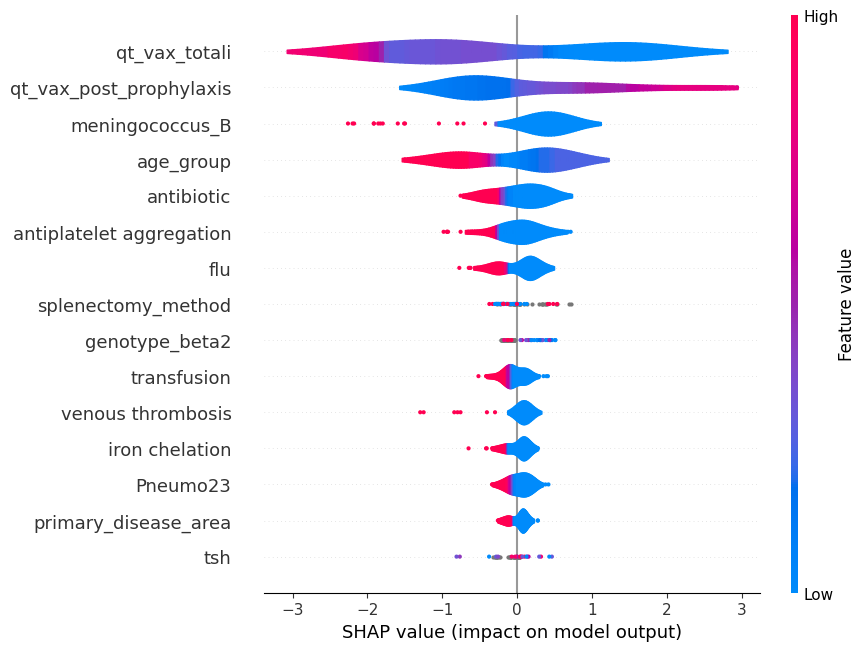

In [15]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer.shap_values(Xv_df)
shap.plots.violin(shap_values, features=Xv_df, feature_names=Xv_df.columns,max_display=15)


## Heatmaps

In [16]:
from cv_folding import lgbm_cv
results_df, model, X_df, Xv_df, y_train, y_test, results = lgbm_cv(embedder_configs, y_df, selected_ids, methods=["COUNTER"], 
                                                                   random_state=seed, return_metrics=True)
results_df

,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,Brier,CM
COUNTER,0.824795,0.042241,0.682367,0.058811,0.688918,0.103374,0.714333,0.147902,0.572762,0.073122,0.818182,0.034468,0.157477,"[[272, 45], [35, 88]]"


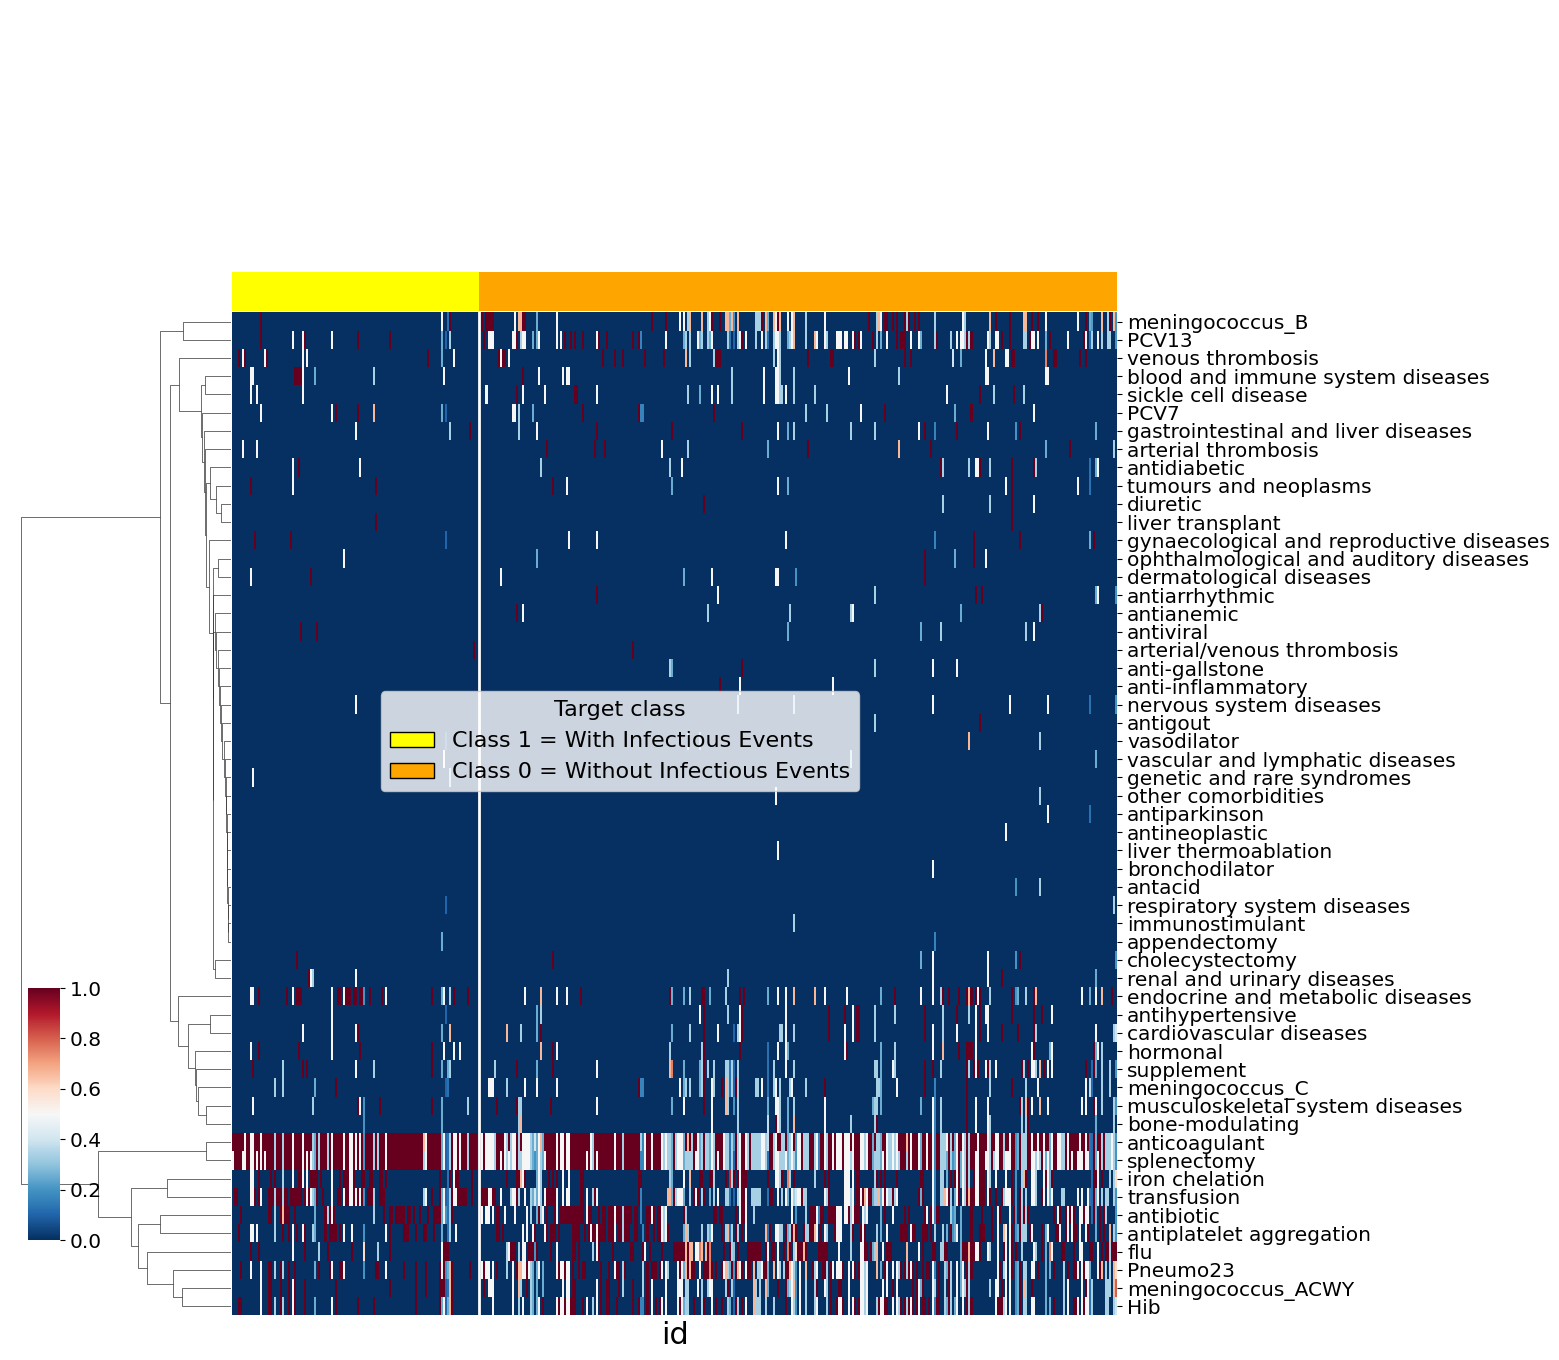

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
import matplotlib as mpl

mpl.rcParams['font.size'] = 20  # Dimensione base
mpl.rcParams['axes.titlesize'] = 22  # Titolo degli assi
mpl.rcParams['axes.labelsize'] = 22  # Etichette assi
mpl.rcParams['xtick.labelsize'] = 20  # Etichette asse x
mpl.rcParams['ytick.labelsize'] = 14.5  # Etichette asse y
mpl.rcParams['legend.fontsize'] = 16  # Font della legenda
mpl.rcParams['legend.title_fontsize'] = 16  # Titolo legenda

# Step 2: Rinomina le colonne nel DataFrame
X_df_traslated = pd.concat([X_df, Xv_df], axis=0)

# Aggiungi la colonna target temporaneamente per colorare le righe
X_df_traslated['target'] = y_df.loc[X_df_traslated.index, 'target']
X_sorted = X_df_traslated.sort_values('target', ascending=False)
targets_sorted = X_sorted['target'].values
X_sorted = X_sorted.drop(columns='target')


X_norm = X_sorted.copy()
X_norm_t = X_norm.T
scaler = MinMaxScaler()
X_norm_t.iloc[:, :] = scaler.fit_transform(X_norm_t)


# Applica la selezione sulle righe (trasponi, applica, poi ritrasponi)
X_filtered = X_norm_t[~(X_norm_t == 0).all(axis=1)]


# 2. (Facoltativo) Rimuovi righe duplicate
# len(X_final) = X_filtered.drop_duplicates()


# Crea una palette per distinguere classi (ad esempio 1=red, 0=blue)
row_colors = ['yellow' if y_df.loc[idx, 'target'] == 1 else 'orange' for idx in X_filtered.columns]


legend_elements = [Patch(facecolor='yellow', edgecolor='k', label='Class 1 = With Infectious Events'),
                   Patch(facecolor='orange', edgecolor='k', label='Class 0 = Without Infectious Events')]

g = sns.clustermap(
    X_filtered,
    cmap='RdBu_r',
    cbar_pos=(0.03, 0.1, 0.02, 0.18),
    figsize=(16, 14),
    col_colors=row_colors,
    xticklabels=False,
    yticklabels=True,
    col_cluster=False,
    row_cluster=True,
    metric='euclidean',
    method='ward'
)


# Calcola quante righe hanno target 1 (sono state messe in alto)
n_positive = sum(y_df.loc[X_filtered.columns, 'target'] == 1)

# Aggiungi linea orizzontale tra target 1 e 0
g.ax_heatmap.axvline(x=n_positive, color='white', linestyle='-', linewidth=2)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels())
# Aggiungi legenda
plt.gcf().legend(handles=legend_elements, title='Target class',
                 loc='upper center', bbox_to_anchor=(0.4, 0.5))
# plt.title("Clustered Heatmap (Sorted by Target)", pad=20)
plt.show()


# print("NaN totali:", X_filtered.isna().sum().sum())
# print("Inf totali:", np.isinf(X_filtered.to_numpy()).sum())
# X_norm_t.shape

# Statistical Analysis

In [18]:
import pandas as pd
import itertools
from scipy.stats import friedmanchisquare, wilcoxon
import statsmodels.stats.multitest as smm

# ======================
# LOAD DATA
# ======================
with open(f"{results_dir}/rawmeas_{niter}iter_{groupname}{subgroup}.pkl", 'rb') as f:
    ff = pickle.load(f)
df = pd.DataFrame({m: ff['MCC'][m] for m in methods})
df

,STATIC,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole
0,0.648886,0.770833,0.745800,0.638311,0.713542,0.674791,0.799060,0.681026,0.648886,0.703646
1,0.512195,0.604524,0.563884,0.541667,0.576066,0.495209,0.674791,0.498239,0.516398,0.689222
2,0.466667,0.621585,0.576066,0.567367,0.452648,0.567367,0.712951,0.485507,0.466667,0.617670
3,0.619025,0.741941,0.800132,0.555113,0.576066,0.509749,0.620406,0.652580,0.534047,0.557364
4,0.597546,0.772249,0.802377,0.728301,0.769581,0.683749,0.888735,0.712951,0.617670,0.829621


### Wiloxon pair-wise test

In [19]:
# ======================
# FRIEDMAN TEST
# ======================
stat, p = friedmanchisquare(*[df[col] for col in df.columns])

print("\n=== FRIEDMAN TEST ===")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p:.6f}")

if p < 0.05:
    print("➡️ Differenze globali SIGNIFICATIVE")
else:
    print("➡️ Nessuna differenza globale")

alpha = 0.05

# ========================
# WILCOXON POST-HOC + HOLM
# ========================
pairs = list(itertools.combinations(df.columns, 2))

wilcoxon_raw_p = []
wilcoxon_results = []

for a, b in pairs:
    try:
        stawinst, pval = wilcoxon(df[a], df[b])
    except ValueError:
        stat, pval = None, 1.0
    wilcoxon_raw_p.append(pval)
    wilcoxon_results.append((a, b, stat, pval))

wilcoxon_reject, wilcoxon_p_corr, _, _ = smm.multipletests(
    wilcoxon_raw_p, alpha=alpha, method="holm"
)

print("\n" + "="*60)
print("WILCOXON PAIRWISE POST-HOC + HOLM")
print("="*60)

found_sig = False
for i, (a, b, stat, pval) in enumerate(wilcoxon_results):
    if wilcoxon_reject[i]:
        found_sig = True
        print(f"✅ {a} vs {b} | raw p = {pval:.6f} | Holm p = {wilcoxon_p_corr[i]:.6f}")

if not found_sig:
    print("wins❌ Nessuna coppia significativa dopo correzione Holm")

print("\nDettaglio completo Wilcoxon:")
for i, (a, b, stat, pval) in enumerate(wilcoxon_results):
    mark = "✅" if wilcoxon_reject[i] else "  "
    print(f"{mark} {a:>8s} vs {b:<8s} | raw p = {pval:.6f} | Holm p = {wilcoxon_p_corr[i]:.6f}")
import numpy as np

methods = list(df.columns)
n = len(methods)

# correct p-value matrix
p_matrix = np.ones((n, n))

# fill-in the matrix
k = 0
for i in range(n):
    for j in range(i+1, n):
        p_matrix[i, j] = wilcoxon_p_corr[k]
        p_matrix[j, i] = wilcoxon_p_corr[k]
        k += 1
pd.DataFrame(p_matrix, columns=methods, index = methods)


=== FRIEDMAN TEST ===
Statistic: 30.5912
p-value: 0.000348
➡️ Differenze globali SIGNIFICATIVE

WILCOXON PAIRWISE POST-HOC + HOLM
wins❌ Nessuna coppia significativa dopo correzione Holm

Dettaglio completo Wilcoxon:
     STATIC vs BINARY   | raw p = 0.062500 | Holm p = 1.000000
     STATIC vs DOME     | raw p = 0.062500 | Holm p = 1.000000
     STATIC vs LSTM     | raw p = 0.437500 | Holm p = 1.000000
     STATIC vs tLSTM    | raw p = 0.312500 | Holm p = 1.000000
     STATIC vs GRU      | raw p = 0.812500 | Holm p = 1.000000
     STATIC vs GRU-D    | raw p = 0.062500 | Holm p = 1.000000
     STATIC vs BEHRT    | raw p = 0.125000 | Holm p = 1.000000
     STATIC vs RETAIN   | raw p = 1.000000 | Holm p = 1.000000
     STATIC vs Dipole   | raw p = 0.187500 | Holm p = 1.000000
     BINARY vs DOME     | raw p = 1.000000 | Holm p = 1.000000
     BINARY vs LSTM     | raw p = 0.062500 | Holm p = 1.000000
     BINARY vs tLSTM    | raw p = 0.062500 | Holm p = 1.000000
     BINARY vs GRU      | r

,STATIC,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole
STATIC,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BINARY,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
DOME,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
LSTM,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
tLSTM,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
GRU,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
GRU-D,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BEHRT,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
RETAIN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Dipole,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Wilcoxon ranking (Win cout)

In [20]:
import pandas as pd

methods = list(df.columns)
n = len(methods)

# inizializza punteggi
wins = {m: 0 for m in methods}
losses = {m: 0 for m in methods}

k = 0
for i in range(n):
    for j in range(i+1, n):
        a = methods[i]
        b = methods[j]
        
        if wilcoxon_reject[k]:  # significativo
            # chi ha media maggiore?
            if df[a].mean() > df[b].mean():
                wins[a] += 1
                losses[b] += 1
            else:
                wins[b] += 1
                losses[a] += 1
        k += 1

# crea dataframe ranking
ranking_df = pd.DataFrame({
    "wins": wins,
    "losses": losses
})
ranking_df["score"] = ranking_df["wins"] - ranking_df["losses"]
ranking_df = ranking_df.sort_values(by="score", ascending=False)
ranking_df

,wins,losses,score
STATIC,0,0,0
BINARY,0,0,0
DOME,0,0,0
LSTM,0,0,0
tLSTM,0,0,0
GRU,0,0,0
GRU-D,0,0,0
BEHRT,0,0,0
RETAIN,0,0,0
Dipole,0,0,0


## Calibration analysis

In [21]:
import pickle
with open(f"{results_dir}/rawmeas_1iter_{groupname}{subgroup}.pkl", 'rb') as f:
    results = pickle.load(f)
prob_pred = {}
prob_true = {}
all_runs = {}
for method in methods:
    prob_pred[method] = results['calibration_prob_pred'][method]
    prob_true[method] = results['calibration_prob_true'][method]
    all_runs[method] = (results['y_true_oof'][method], results['y_prob_oof'][method])

### draw calibration curves

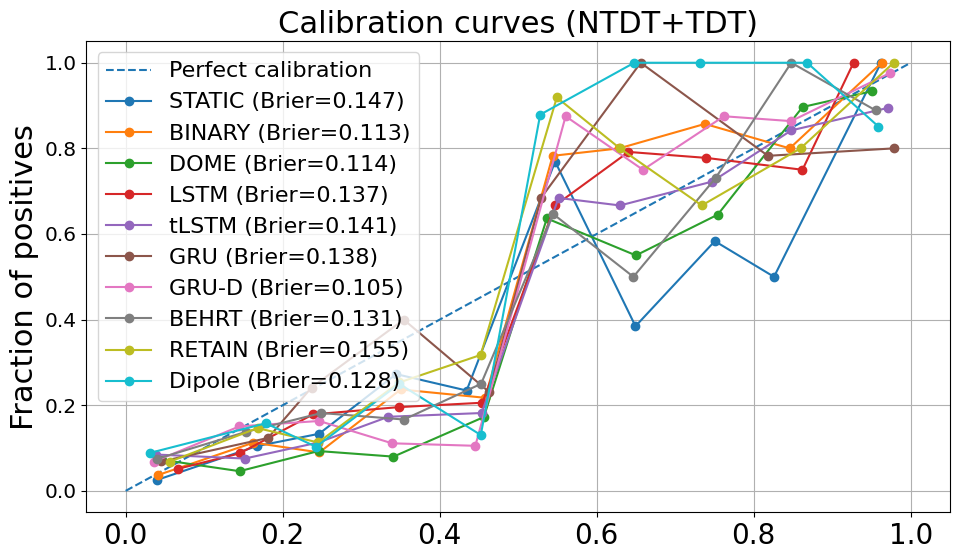

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from math import ceil
from sklearn.metrics import brier_score_loss

def plot_calibration(prob_pred, prob_true, all_runs, title="Calibration curves"):

    methods = list(prob_pred.keys())
    n_models = len(methods)

    # 🎨 colori consistenti
    cmap = plt.get_cmap("tab10")
    colors = {m: cmap(i) for i, m in enumerate(methods)}

    # Crea figura e asse
    fig, ax_cal = plt.subplots(figsize=(10, 6))
    
    # =========================
    # CALIBRATION CURVE
    # =========================
    ax_cal.plot([0, 1], [0, 1], '--', label='Perfect calibration')

    for i, m in enumerate(methods):
        x = np.array(list(itertools.chain(*prob_pred[m])))
        y = np.array(list(itertools.chain(*prob_true[m])))
        y_true_oof, y_prob_oof = np.array(list(itertools.chain(*all_runs[m][0]))), np.array(list(itertools.chain(*all_runs[m][1]))) #all_runs[m]
        brier = brier_score_loss(y_true_oof, y_prob_oof)

        color = colors[m]

        ax_cal.plot(
            x, y,
            marker='o',
            color=color,
            label=f"{m} (Brier={brier:.3f})"
        )

    ax_cal.set_title(title)
    ax_cal.set_ylabel("Fraction of positives")
    ax_cal.legend(loc="upper left")
    ax_cal.grid(True)

    plt.tight_layout()
    plt.show()

plot_calibration(prob_pred, prob_true, 
                                all_runs,  
                                title=f"Calibration curves ({groupname})")